# Empirical Ordinal-Grid Landscape

When the variables are numeric and sampled on a discrete grid (compositions, temperatures, pH, concentrations, …), they should be declared `ordinal`. The encoded codes then preserve value ordering.

As a demo, we use the W-Re-Os refractory alloy library from:

Yong Wang *et al.*, "High-throughput discovery of ultrahigh-temperature multi-principal element alloys by combinatorial additive manufacturing," *Nat. Commun.* **17**, 668 (2026). 496 alloys on a 3 at.% ternary simplex; fitness is the paper's TOPSIS composite score `Ci`.

The compositions obey `W + Re + Os = 100`, so we build the landscape over `(W, Re)` and let `Os` be implicit — otherwise no two configurations could ever differ in exactly one axis.

## 1. Load the data

In [1]:
import pandas as pd

df = pd.read_csv('../data/Materials/WReOs/simplex.csv')
df.head()

,composition_id,W,Re,Os,H25_HV,H1000_HV,R1000,pileup_um,TOPSIS_Ci,phase_label
0,W3Re3Os94,3,3,94,741,411,0.55,0.1,0.22,HCP
1,W3Re6Os91,3,6,91,793,423,0.53,0.4,0.21,HCP
2,W3Re9Os88,3,9,88,794,442,0.56,0.0,0.23,HCP
3,W3Re12Os85,3,12,85,794,460,0.58,0.0,0.26,HCP
4,W3Re15Os82,3,15,82,768,454,0.59,0.0,0.27,HCP


## 2. Build the landscape

In [2]:
from graphfla.landscape import Landscape

X = df[['W', 'Re']]
f = df['TOPSIS_Ci']

landscape = Landscape(maximize=True)
landscape.build_from_data(
    X, f,
    data_types={'W': 'ordinal', 'Re': 'ordinal'},
    verbose=True,
)

Building Landscape from data...
 - Validating data types dictionary...
   - Data types dictionary validation successful.
 - Handling missing values and duplicates...
 - Checking for missing values...
 - Handling duplicate configurations...
   - No duplicate configurations found.
Preparing data for landscape construction (encoding variables)...
Constructing landscape graph...


Output()

 - Identified 768 improving connections.
 - Identified 162 neutral neighbor pairs.
 - Constructing graph object...
 - Adding node attributes (fitness, etc.)...
 - Identified 68 neutral plateaus covering 224 nodes.
Calculating landscape properties...
 - Calculating network metrics (degrees)...
 - Determining local optima...
   - Found 32 local optima (41 member nodes: 5 plateau-LOs + 27 single-point LOs).
 - Determining global optimum...
   - Global optimum found at index 334 with fitness 0.6300.
Landscape built successfully.



Landscape(kind='default', maximize=True)

## 3. Basic information

In [3]:
print(f"Size: {len(landscape)}")
print(f"Dimension: {landscape.n_vars}")
print(f"Number of local optima: {landscape.n_lo}")
print(f"Global optimum index: {landscape.go_index}")
print("Global optimum information:")
print(landscape[landscape.go_index])

Size: 496
Dimension: 2
Number of local optima: 32
Global optimum index: 334
Global optimum information:
{'W': np.int64(42), 'Re': np.int64(30), 'fitness': np.float64(0.63), 'plateau_id': -1, 'plateau_size': 1, 'in_degree': 4, 'out_degree': 0, 'is_lo': True}


## 4. Spatial fitness map

With only two axes, the landscape can be rendered directly.

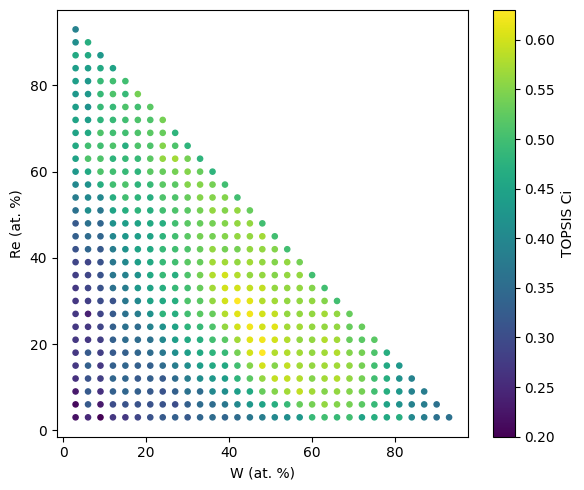

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(df['W'], df['Re'], c=df['TOPSIS_Ci'], cmap='viridis', s=14)
ax.set_xlabel('W (at. %)'); ax.set_ylabel('Re (at. %)')
plt.colorbar(sc, ax=ax, label='TOPSIS Ci')
plt.tight_layout()

## 5. Landscape features

In [5]:
from graphfla.analysis import (
    local_optima_ratio, autocorrelation, fdc,
)

print(f"lo_ratio:        {local_optima_ratio(landscape):.4f}")
print(f"autocorrelation: {autocorrelation(landscape):.4f}")
print(f"fdc:             {fdc(landscape):.4f}")


 - Calculating distances to global optimum using mixed_distance...
   - Distances to GO calculated and added as node attribute 'dist_go'.


lo_ratio:        0.0645
autocorrelation: 0.9025
fdc:             -0.5399


### The whole feature panel in one call

`analysis.profile()` runs every whole-landscape metric and returns a tidy `pandas` Series — the computed-metric companion to `landscape.describe()`. Pass a list of landscapes to get a `DataFrame`, one row each, for side-by-side comparison.

In [6]:
from graphfla import analysis

# one call -> a pandas Series of every whole-landscape metric
analysis.profile(landscape)

Output()

✓ fitness_distribution                0.0s

✓ local_optima_ratio                  0.0s

✓ gradient_intensity                  0.0s

✓ autocorrelation                     0.0s

...

✓ extradimensional_bypass             0.0s

✓ profiled 22 features in 3.5s

! 1 warning(s) during profiling:

/Users/arwen/Documents/GitHub/GraphFLA/graphfla/analysis/correlation.py:179: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation, p_value = spearmanr(index, differences)


fitness.skewness                      -0.556499
fitness.kurtosis                       2.302710
fitness.cv                             0.209693
fitness.quartile_coefficient           0.306122
fitness.median_mean_ratio              1.060662
fitness.relative_range                 0.877551
fitness.cauchy_loc                     0.492562
local_optima_ratio                     0.064516
gradient_intensity                     0.054144
autocorrelation                        0.901357
r_s_ratio                              6.121382
neutrality                             0.230108
evolvability_enhancing_mutations       0.727865
fdc                                   -0.539896
basin_fitness_correlation              0.120851
neighbor_fitness_correlation           0.985112
fitness_flattening_index              -0.098690
global_optima_accessibility            0.237903
mean_path_length_to_global_optimum     8.008475
mean_distance_to_global_optimum       11.560484
gamma                                  0